### Install required libraries

Using torchaudio==2.8 here as 2.9 forces the use of torchcodec:

In [65]:
%pip install --upgrade pip
%pip install pandas numpy matplotlib torch torchaudio==2.8 soundfile --quiet

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Imports

In [66]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchaudio
from IPython.display import Audio
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm

from src.audio_dataset import AudioDataset
from src.cnn_model import AudioClassifier
from src.preprocessing import get_transformation_pipeline, FixAudioLength

### Constants

In [67]:
INPUT_DIR = 'data'
MODEL_PATH = 'models/best_cnn.pth'

# Audio
ORIGINAL_SAMPLE_RATE = 48_000
TARGET_SAMPLE_RATE = 16_000
TARGET_AUDIO_LENGTH = 0.84
TARGET_SAMPLES = int(TARGET_SAMPLE_RATE * TARGET_AUDIO_LENGTH)
NUM_MELS = 64

# Hyperparameters
LR = 0.001
NUM_EPOCHS = 10

### Setting up device to use

In [68]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Using device: {device}')

Using device: mps


### Visualising audio data

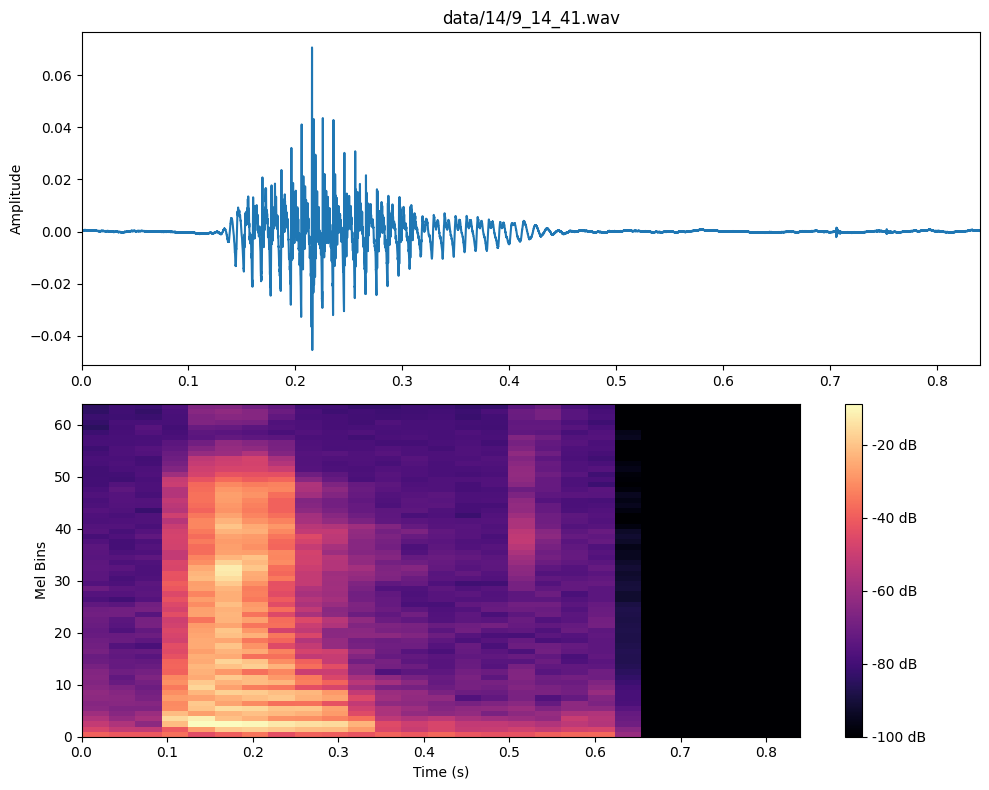

Old samples: 29642
Old duration: 0.62s
New samples: 13440
New duration: 0.84s


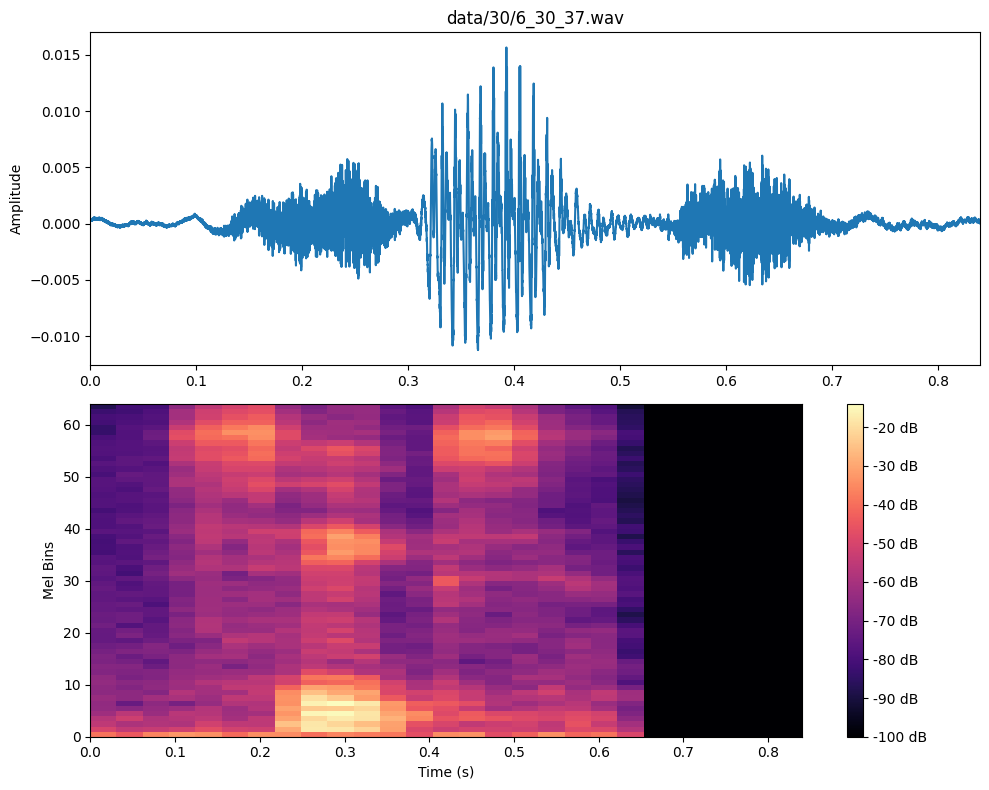

Old samples: 30117
Old duration: 0.63s
New samples: 13440
New duration: 0.84s


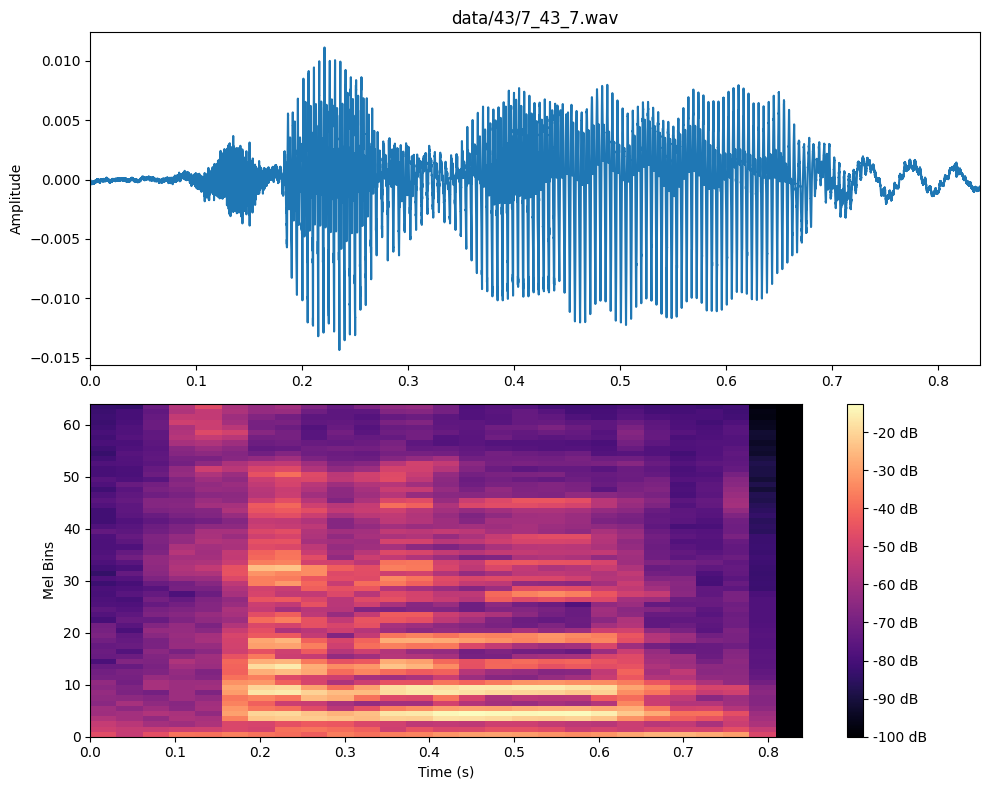

Old samples: 37468
Old duration: 0.78s
New samples: 13440
New duration: 0.84s


In [69]:
def visualise_audio_data() -> None:
    resampler = torchaudio.transforms.Resample(
        orig_freq=ORIGINAL_SAMPLE_RATE,
        new_freq=TARGET_SAMPLE_RATE
    )
    pipeline = get_transformation_pipeline()

    for i in range(3):
        # Randomly select a digit, speaker and sample
        digit = np.random.randint(0, 10)
        speaker = np.random.randint(1, 61)
        sample = np.random.randint(0, 50)

        if speaker < 10:
            file = f'{INPUT_DIR}/0{speaker}/{digit}_0{speaker}_{sample}.wav'
        else:
            file = f'{INPUT_DIR}/{speaker}/{digit}_{speaker}_{sample}.wav'

        # Do the resampling + audio length fixing here so we have access to the modified waveform
        waveform, sample_rate = torchaudio.load(file, normalize=True)
        old_samples = waveform.shape[1]
        old_duration = waveform.shape[1] / sample_rate

        new_waveform = FixAudioLength()(resampler(waveform))
        new_sample_rate = TARGET_SAMPLE_RATE
        new_samples = new_waveform.shape[1]
        new_duration = new_waveform.shape[1] / new_sample_rate

        mel_spectrogram = pipeline(waveform)

        # Plotting
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=False)

        # Waveform
        ax1.plot(np.linspace(0, new_duration, waveform.shape[1]), waveform.t().numpy())
        ax1.set_xlim(0, new_duration)
        ax1.set_title(file)
        ax1.set_ylabel('Amplitude')

        # Mel Spectrogram
        img = ax2.imshow(
            mel_spectrogram[0].numpy(),
            origin='lower',
            aspect='auto',
            cmap='magma',
            extent=[0, new_duration, 0, NUM_MELS],
        )
        ax2.set_ylabel('Mel Bins')
        ax2.set_xlabel('Time (s)')
        fig.colorbar(img, ax=ax2, format='%+2.0f dB')

        plt.tight_layout()
        plt.show()

        display(Audio(data=waveform, rate=sample_rate))
        print(f'Old samples: {old_samples}')
        print(f'Old duration: {old_duration:.2f}s')
        print(f'New samples: {new_samples}')
        print(f'New duration: {new_duration:.2f}s')

visualise_audio_data()

### Determining the 95th percentile for audio lengths

In [70]:
# Need this to be able to determine the best time to truncate / pad to
def calculate_audio_lengths() -> None:
    audio_files = glob.glob(os.path.join(INPUT_DIR, '**/*.wav'), recursive=True)

    durations = []
    for file in tqdm(audio_files):
        info = torchaudio.info(file)
        duration = info.num_frames / info.sample_rate
        durations.append(duration)

    durations = np.array(durations)

    plt.hist(durations, bins=60)
    plt.title('Distribution of audio durations')
    plt.xlabel('Seconds')
    plt.ylabel('No. of files')
    plt.show()

    print(f'95% percentile: {np.percentile(durations, 95):.2f}s')

### Training, validation and testing code

In [71]:
def train(model, train_dataloader, optimizer, criterion) -> float:
    model.train()

    total_loss = 0.0
    for data in tqdm(train_dataloader, desc='Training', unit='batches'):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_dataloader)

def validate(model, val_dataloader, criterion) -> tuple[float, float]:
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for data in tqdm(val_dataloader, desc='Validation', unit='batches'):
            inputs, labels = data[0].to(device), data[1].to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(val_dataloader)
    avg_accuracy = 100 * correct / total

    return avg_loss, avg_accuracy

def test(model, test_dataloader) -> float:
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model = model.to(device)

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for data in tqdm(test_dataloader, desc='Testing', unit='batches'):
            inputs, labels = data[0].to(device), data[1].to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    accuracy = 100 * correct / total
    return accuracy

### Training script

In [ ]:
if __name__ == '__main__':
    # Define our dataset and dataloaders
    dataset = AudioDataset(data_dir=INPUT_DIR, pipeline=get_transformation_pipeline())

    # Split dataset into training, validation and test sets
    # Using an 80/10/10 split
    train_size = int(0.8 * len(dataset))
    val_size = int(0.1 * len(dataset))
    test_size = len(dataset) - train_size - val_size

    train_dataset, val_dataset, test_dataset = random_split(
        dataset, [train_size, val_size, test_size],
    )

    train_dataloader = DataLoader(train_dataset, batch_size=32, num_workers=4, shuffle=True, drop_last=True)
    val_dataloader = DataLoader(val_dataset, batch_size=32, num_workers=4)
    test_dataloader = DataLoader(test_dataset, batch_size=32, num_workers=4)

    # Get one batch from the training loader and make sure it looks good
    features, labels = next(iter(train_dataloader))
    print(f'Features shape: {features.shape}')
    print(f'Labels shape: {labels.shape}')
    print()

    # Train the model
    model = AudioClassifier().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    # Keep track of best model
    best_accuracy = 0.0
    for epoch in range(NUM_EPOCHS):
        saved = False

        print(f'[Epoch {epoch + 1}/{NUM_EPOCHS}]')
        train_loss = train(model, train_dataloader, optimizer, criterion)
        val_loss, accuracy = validate(model, val_dataloader, criterion)

        if (accuracy > best_accuracy):
            saved = True
            best_accuracy = accuracy
            torch.save(model.state_dict(), MODEL_PATH)

        print(f'Training Loss: {train_loss:.2f} | Validation Loss: {val_loss:.2f} | Accuracy: {accuracy:.2f}%')
        print()
    print(f'Best model had an accuracy of {best_accuracy:.2f}%.')
    print(f'Running final test:')
    test_accuracy = test(model, test_dataloader)
    print(f'Final test accuracy: {test_accuracy:.2f}%')

Features shape: torch.Size([32, 1, 64, 27])
Labels shape: torch.Size([32])

[Epoch 1/10]


Training:  23%|██▎       | 169/750 [00:05<00:08, 71.02batches/s]